## Ploting geospatial data - basin and river network

In [2]:
import os
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np

def plot_merit_basins_comparison_exact(
    subbasins_raw_path,
    rivers_raw_path,
    subbasins_agg_path,
    rivers_agg_path,
    dissolved_basin_path,
    border_path,
    output_png='merit_hydro_subbasins.png',
    figsize=(16, 8),
    dpi=300
):
    """
    Recreates your original plot EXACTLY — same look, same parameters.
    Only change: all paths are input arguments. No visual differences.
    """

    # Load and reproject to WGS84
    sub_noagg_gdf = gpd.read_file(subbasins_raw_path).to_crs(epsg=4326)
    riv_noagg_gdf = gpd.read_file(rivers_raw_path).to_crs(epsg=4326)
    sub_agg_gdf   = gpd.read_file(subbasins_agg_path).to_crs(epsg=4326)
    riv_agg_gdf   = gpd.read_file(rivers_agg_path).to_crs(epsg=4326)
    dissolved_basin = gpd.read_file(dissolved_basin_path).to_crs(epsg=4326)
    border = gpd.read_file(border_path).to_crs(epsg=4326)
    
    # Convert COMID to int (as in original)
    for gdf in [sub_noagg_gdf, sub_agg_gdf, riv_noagg_gdf, riv_agg_gdf]:
        if 'COMID' in gdf.columns:
            gdf['COMID'] = gdf['COMID'].astype(int)
        if 'SubId' in gdf.columns:
            gdf['SubId'] = gdf['SubId'].astype(int)
        if 'Strahler' in gdf.columns:
            gdf['order'] = gdf['Strahler']


    # Create figure
    fig, axs = plt.subplots(1, 2, figsize=figsize)
    
    # ==================== LEFT PLOT (Original) ====================
    sub_noagg_gdf.plot(ax=axs[0], color='white', edgecolor='black', alpha=0.8, linewidth=0.10, zorder=1)
    riv_noagg_gdf.plot(ax=axs[0], color='blue', alpha=1, 
                       linewidth=np.power(0.12 * riv_noagg_gdf['order'], 4), zorder=2)
    dissolved_basin.plot(ax=axs[0], edgecolor='black', facecolor='none', linewidth=0.2)
    border.plot(ax=axs[0], edgecolor='red', linewidth=1.0)

    axs[0].text(0.05, 0.99, f'Minimum sub-basin area: < 0.1 km$^2$', 
                transform=axs[0].transAxes, fontsize=14, verticalalignment='top')
    axs[0].text(0.05, 0.95, f'Number of sub-basins: {len(sub_noagg_gdf)}', 
                transform=axs[0].transAxes, fontsize=14, verticalalignment='top')
    axs[0].text(0.05, 0.91, f'Number of river segments: {len(riv_noagg_gdf)}', 
                transform=axs[0].transAxes, fontsize=14, verticalalignment='top')

    axs[0].set_title('CAMELS-SPAT - Subbasins', fontsize=16)
    axs[0].tick_params(axis='both', which='major', labelsize=12)
    axs[0].set_xlabel('Longitude', fontsize=14)
    axs[0].set_ylabel('Latitude', fontsize=14)

    # ==================== RIGHT PLOT (Aggregated) ====================
    sub_agg_gdf.plot(ax=axs[1], color='white', edgecolor='black', alpha=0.8, linewidth=0.10, zorder=1)
    riv_agg_gdf.plot(ax=axs[1], color='blue', alpha=1,
                     linewidth=np.power(0.12 * riv_agg_gdf['order'], 4), zorder=2)
    dissolved_basin.plot(ax=axs[1], edgecolor='black', facecolor='none', linewidth=0.2)
    border.plot(ax=axs[1], edgecolor='red', linewidth=1.0)

    axs[1].text(0.05, 0.99, f'Minimum sub-basin area: 100 Km$^2$', 
                transform=axs[1].transAxes, fontsize=14, verticalalignment='top')
    axs[1].text(0.05, 0.95, f'Number of sub-basins: {len(sub_agg_gdf)}', 
                transform=axs[1].transAxes, fontsize=14, verticalalignment='top')
    axs[1].text(0.05, 0.91, f'Number of river segments: {len(riv_agg_gdf)}', 
                transform=axs[1].transAxes, fontsize=14, verticalalignment='top')

    axs[1].set_title('CAMELS-SPAT - After Subbasins Aggregation', fontsize=16)
    axs[1].tick_params(axis='both', which='major', labelsize=12)
    axs[1].set_xlabel('Longitude', fontsize=14)
    axs[1].set_yticklabels([])          # removes the labels

    # ==================== Finalize ====================
    plt.tight_layout()
    plt.savefig(output_png, dpi=dpi)
    plt.show()

    print(f"Plot saved as: {os.path.abspath(output_png)}")

In [ ]:
# ====================== EXAMPLE CALL MERIT-HYDRO ======================
if __name__ == "__main__":
    base_dir = '/home/zelalem/github-repos/community-workflows'

    plot_merit_basins_comparison_exact(
        subbasins_raw_path   = os.path.join(base_dir, '1-geofabric/MERIT/CanTrans-merit-geofabric/merit_cantrans_subbasins.shp'),
        rivers_raw_path      = os.path.join(base_dir, '1-geofabric/MERIT/CanTrans-merit-geofabric/merit_cantrans_rivers.shp'),
        subbasins_agg_path   = os.path.join(base_dir, '1-geofabric/MERIT/CanTrans-merit-geofabric/agg_MERIT_CanTrans_subbasins.shp'),
        rivers_agg_path      = os.path.join(base_dir, '1-geofabric/MERIT/CanTrans-merit-geofabric/agg_MERIT_CanTrans_rivers.shp'),
        dissolved_basin_path = os.path.join(base_dir, '1-geofabric/study-domain/CanTrans_MERIT_StudyDomain.shp'),
        border_path          = os.path.join(base_dir, '1-geofabric/study-domain/US-Canada_Boundary_v1_3.shp'),
        output_png           = 'merit_hydro_subbasins_exact.png',
        dpi                  = 300
    )

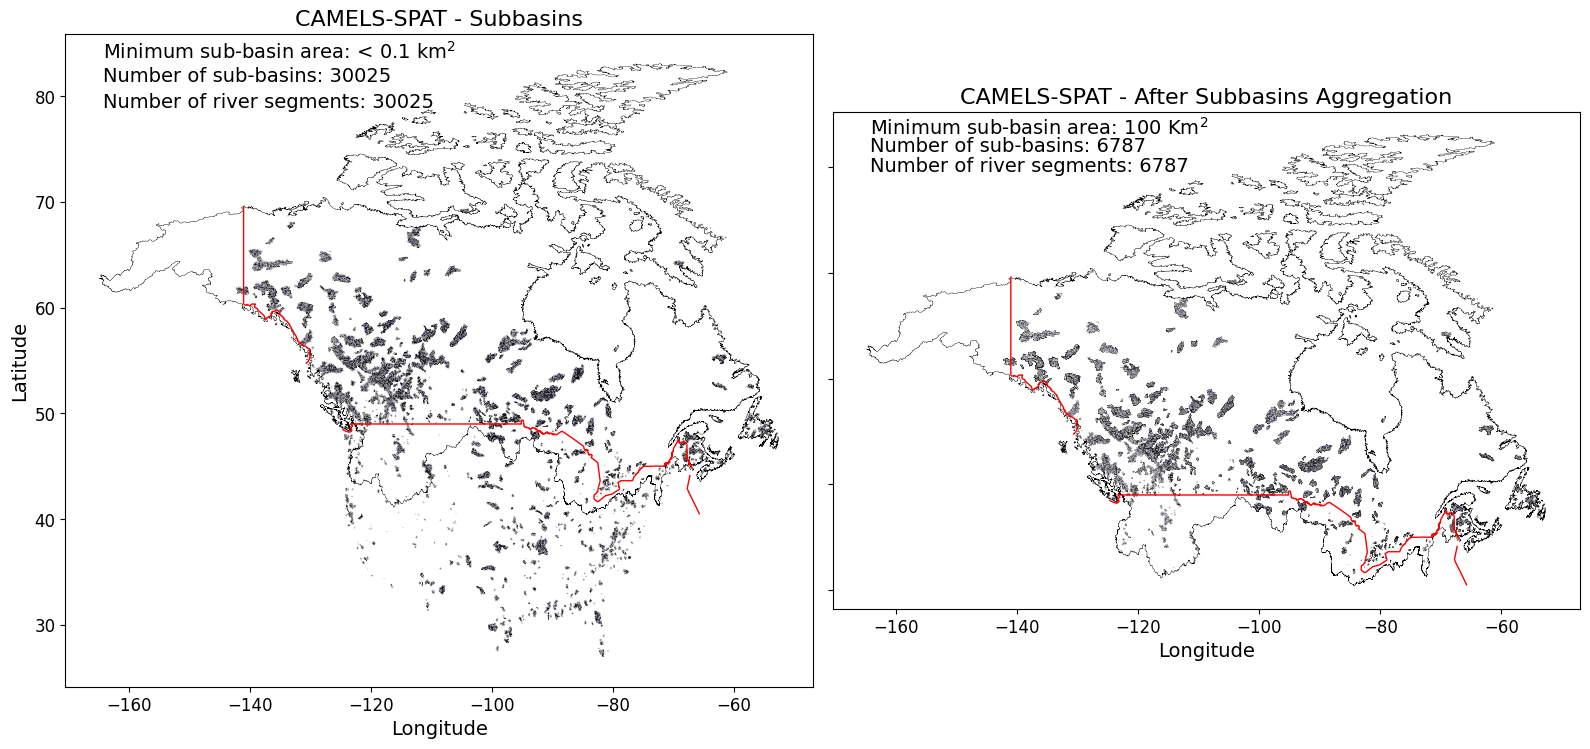

Plot saved as: /home/zelalem/github-repos/community-workflows/6-plottings/camels-spat_merit_hydro_subbasins_exact.png


In [3]:
# ====================== EXAMPLE CALL CAMELS-SPAT ======================
if __name__ == "__main__":
    base_dir = '/home/zelalem/github-repos/community-workflows'

    plot_merit_basins_comparison_exact(
        subbasins_raw_path   = os.path.join(base_dir, '1-geofabric/CAMELS-SPAT/merged_lamped/all_scales_merged_basins.shp'),
        rivers_raw_path      = os.path.join(base_dir, '1-geofabric/CAMELS-SPAT/merged_lamped/all_scales_merged_rivers_plus_generated.shp'),
        subbasins_agg_path   = os.path.join(base_dir, '1-geofabric/CAMELS-SPAT/merged_lamped/agg_CAMELS-MERIT_CanTrans_subbasins.shp'),
        rivers_agg_path      = os.path.join(base_dir, '1-geofabric/CAMELS-SPAT/merged_lamped/agg_CAMELS-MERIT_CanTrans_rivers.shp'),
        dissolved_basin_path = os.path.join(base_dir, '1-geofabric/study-domain/CanTrans_MERIT_StudyDomain.shp'),
        border_path          = os.path.join(base_dir, '1-geofabric/study-domain/US-Canada_Boundary_v1_3.shp'),
        output_png           = 'camels-spat_merit_hydro_subbasins_exact.png',
        dpi                  = 300
    )

In [ ]:
import os
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np


def plot_merit_basins_comparison_exact(
    subbasins_raw_path,
    rivers_raw_path,
    subbasins_agg_path,
    rivers_agg_path,
    dissolved_basin_path,
    border_path,
    output_png='merit_hydro_subbasins.png',
    figsize=(16, 8),
    dpi=300
):
    """
    Recreates the original plot with correct feature counts.
    Fixes:
    - Handles multipart geometries
    - Removes duplicated rows
    - Cleans preprocessing logic
    """

    # ============================
    # Load data
    # ============================
    sub_noagg_gdf = gpd.read_file(subbasins_raw_path).to_crs(epsg=4326)
    riv_noagg_gdf = gpd.read_file(rivers_raw_path).to_crs(epsg=4326)
    sub_agg_gdf   = gpd.read_file(subbasins_agg_path).to_crs(epsg=4326)
    riv_agg_gdf   = gpd.read_file(rivers_agg_path).to_crs(epsg=4326)
    dissolved_basin = gpd.read_file(dissolved_basin_path).to_crs(epsg=4326)
    border = gpd.read_file(border_path).to_crs(epsg=4326)

    sub_noagg_gdf["geometry"] = sub_noagg_gdf.geometry.simplify(
        tolerance=0.0005,
        preserve_topology=True)
    
    # ============================
    # Explode multipart geometries
    # ============================
    sub_noagg_gdf = sub_noagg_gdf.explode(index_parts=False)
    riv_noagg_gdf = riv_noagg_gdf.explode(index_parts=False)
    sub_agg_gdf   = sub_agg_gdf.explode(index_parts=False)
    riv_agg_gdf   = riv_agg_gdf.explode(index_parts=False)

    # ============================
    # Clean attributes
    # ============================
    for gdf in [sub_noagg_gdf, sub_agg_gdf, riv_noagg_gdf, riv_agg_gdf]:

        if 'COMID' in gdf.columns:
            gdf['COMID'] = gdf['COMID'].astype(int)

        if 'SubId' in gdf.columns:
            gdf['SubId'] = gdf['SubId'].astype(int)

        if 'Strahler' in gdf.columns:
            gdf['order'] = gdf['Strahler']

    # ============================
    # Remove duplicates (if present)
    # ============================
    if 'SubId' in sub_noagg_gdf.columns:
        sub_noagg_gdf = sub_noagg_gdf.drop_duplicates(subset='SubId')

    if 'COMID' in riv_noagg_gdf.columns:
        riv_noagg_gdf = riv_noagg_gdf.drop_duplicates(subset='COMID')

    if 'SubId' in sub_agg_gdf.columns:
        sub_agg_gdf = sub_agg_gdf.drop_duplicates(subset='SubId')

    if 'COMID' in riv_agg_gdf.columns:
        riv_agg_gdf = riv_agg_gdf.drop_duplicates(subset='COMID')

    # ============================
    # Debug counts
    # ============================
    print("---- Feature Counts ----")
    print("Raw Subbasins:", len(sub_noagg_gdf))
    print("Raw Rivers:", len(riv_noagg_gdf))
    print("Aggregated Subbasins:", len(sub_agg_gdf))
    print("Aggregated Rivers:", len(riv_agg_gdf))
    print("------------------------")

    # ============================
    # Create figure
    # ============================
    fig, axs = plt.subplots(1, 2, figsize=figsize)

    # ============================
    # LEFT PANEL (Original)
    # ============================
    sub_noagg_gdf.plot(
        ax=axs[0],
        color='white',
        edgecolor='black',
        alpha=0.8,
        linewidth=0.10,
        zorder=1
    )

    riv_noagg_gdf.plot(
        ax=axs[0],
        color='blue',
        alpha=1,
        linewidth=np.power(0.12 * riv_noagg_gdf['order'], 4),
        zorder=2
    )

    dissolved_basin.plot(
        ax=axs[0],
        edgecolor='black',
        facecolor='none',
        linewidth=0.2
    )

    border.plot(
        ax=axs[0],
        edgecolor='red',
        linewidth=1.0
    )

    axs[0].text(
        0.05, 0.99,
        'Minimum sub-basin area: < 0.1 km$^2$',
        transform=axs[0].transAxes,
        fontsize=14,
        verticalalignment='top'
    )

    axs[0].text(
        0.05, 0.95,
        f'Number of sub-basins: {len(sub_noagg_gdf)}',
        transform=axs[0].transAxes,
        fontsize=14,
        verticalalignment='top'
    )

    axs[0].text(
        0.05, 0.91,
        f'Number of river segments: {len(riv_noagg_gdf)}',
        transform=axs[0].transAxes,
        fontsize=14,
        verticalalignment='top'
    )

    axs[0].set_title('CLRH - Subbasins', fontsize=16)
    axs[0].tick_params(axis='both', which='major', labelsize=12)
    axs[0].set_xlabel('Longitude', fontsize=14)
    axs[0].set_ylabel('Latitude', fontsize=14)

    # ============================
    # RIGHT PANEL (Aggregated)
    # ============================
    sub_agg_gdf.plot(
        ax=axs[1],
        color='white',
        edgecolor='black',
        alpha=0.8,
        linewidth=0.10,
        zorder=1
    )

    riv_agg_gdf.plot(
        ax=axs[1],
        color='blue',
        alpha=1,
        linewidth=np.power(0.12 * riv_agg_gdf['order'], 4),
        zorder=2
    )

    dissolved_basin.plot(
        ax=axs[1],
        edgecolor='black',
        facecolor='none',
        linewidth=0.2
    )

    border.plot(
        ax=axs[1],
        edgecolor='red',
        linewidth=1.0
    )

    axs[1].text(
        0.05, 0.99,
        'Minimum sub-basin area: 100 km$^2$',
        transform=axs[1].transAxes,
        fontsize=14,
        verticalalignment='top'
    )

    axs[1].text(
        0.05, 0.95,
        f'Number of sub-basins: {len(sub_agg_gdf)}',
        transform=axs[1].transAxes,
        fontsize=14,
        verticalalignment='top'
    )

    axs[1].text(
        0.05, 0.91,
        f'Number of river segments: {len(riv_agg_gdf)}',
        transform=axs[1].transAxes,
        fontsize=14,
        verticalalignment='top'
    )

    axs[1].set_title('CLRH - After Subbasins Aggregation', fontsize=16)
    axs[1].tick_params(axis='both', which='major', labelsize=12)
    axs[1].set_xlabel('Longitude', fontsize=14)
    axs[1].set_yticklabels([])

    # ============================
    # Finalize
    # ============================
    plt.tight_layout()
    plt.savefig(output_png, dpi=dpi)
    plt.show()

    print(f"Plot saved as: {os.path.abspath(output_png)}")

In [ ]:
# ====================== EXAMPLE CALL ======================
if __name__ == "__main__":
    base_dir = '/home/zelalem/github-repos/community-workflows'

    plot_merit_basins_comparison_exact(
        subbasins_raw_path   = os.path.join('/home/zelalem/scratch/merged_finalcat_info_v1-0.gpkg'),
        rivers_raw_path      = os.path.join('/home/zelalem/scratch/merged_finalcat_info_riv_v1-0.gpkg'),
        subbasins_agg_path   = os.path.join(base_dir, '1-geofabric/CLRH/CLRH-CanTrans/sorted_finalcat_info_v1-0.shp'),
        rivers_agg_path      = os.path.join(base_dir, '1-geofabric/CLRH/CLRH-CanTrans/sorted_finalcat_info_riv_v1-0.shp'),
        dissolved_basin_path = os.path.join(base_dir, '1-geofabric/study-domain/CanTrans_MERIT_StudyDomain.shp'),
        border_path          = os.path.join(base_dir, '1-geofabric/study-domain/US-Canada_Boundary_v1_3.shp'),
        output_png           = 'clrh_hydro_subbasins_exact.png',
        dpi                  = 300
    )

In [ ]:
import os
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np


def plot_merit_basins_comparison_exact(
    subbasins_raw_path,
    rivers_raw_path,
    subbasins_agg_path,
    rivers_agg_path,
    primary_key,
    dissolved_basin_path,
    border_path,
    output_png='merit_hydro_subbasins.png',
    figsize=(16, 8),
    dpi=300
):

    # -------------------------------------------------
    # Clean geometries safely
    # -------------------------------------------------
    def clean_gdf(gdf):

        gdf = gdf[gdf.geometry.notnull()]
        gdf = gdf[~gdf.geometry.is_empty]

        try:
            gdf = gdf[gdf.is_valid]
        except:
            pass

        return gdf.reset_index(drop=True)

    # -------------------------------------------------
    # Load data
    # -------------------------------------------------
    sub_noagg_gdf = gpd.read_file(subbasins_raw_path).to_crs(epsg=4326)
    riv_noagg_gdf = gpd.read_file(rivers_raw_path).to_crs(epsg=4326)

    sub_agg_gdf = gpd.read_file(subbasins_agg_path).to_crs(epsg=4326)
    riv_agg_gdf = gpd.read_file(rivers_agg_path).to_crs(epsg=4326)

    dissolved_basin = gpd.read_file(dissolved_basin_path).to_crs(epsg=4326)
    border = gpd.read_file(border_path).to_crs(epsg=4326)

    # -------------------------------------------------
    # Clean datasets
    # -------------------------------------------------
    sub_noagg_gdf = clean_gdf(sub_noagg_gdf)
    riv_noagg_gdf = clean_gdf(riv_noagg_gdf)

    sub_agg_gdf = clean_gdf(sub_agg_gdf)
    riv_agg_gdf = clean_gdf(riv_agg_gdf)

    dissolved_basin = clean_gdf(dissolved_basin)
    border = clean_gdf(border)

    # -------------------------------------------------
    # Convert primary key to integer if possible
    # -------------------------------------------------
    for gdf in [sub_noagg_gdf, sub_agg_gdf]:
        if primary_key in gdf.columns:
            try:
                gdf[primary_key] = gdf[primary_key].astype(int)
            except:
                pass

    # -------------------------------------------------
    # Ensure Strahler order exists
    # -------------------------------------------------
    def ensure_order(gdf):

        if 'order' not in gdf.columns and 'Strahler' in gdf.columns:
            gdf['order'] = gdf['Strahler']

        return gdf

    sub_noagg_gdf = ensure_order(sub_noagg_gdf)
    riv_noagg_gdf = ensure_order(riv_noagg_gdf)

    sub_agg_gdf = ensure_order(sub_agg_gdf)
    riv_agg_gdf = ensure_order(riv_agg_gdf)

    # Remove rivers without order
    riv_noagg_gdf = riv_noagg_gdf[riv_noagg_gdf['order'].notna()]
    riv_agg_gdf = riv_agg_gdf[riv_agg_gdf['order'].notna()]

    # -------------------------------------------------
    # Correct feature counts
    # -------------------------------------------------
    n_sub_raw = len(sub_noagg_gdf)
    n_riv_raw = len(riv_noagg_gdf)

    n_sub_agg = len(sub_agg_gdf)
    n_riv_agg = len(riv_agg_gdf)

    # -------------------------------------------------
    # Create figure
    # -------------------------------------------------
    fig, axs = plt.subplots(1, 2, figsize=figsize)

    # ================= LEFT =================
    sub_noagg_gdf.plot(
        ax=axs[0],
        color='white',
        edgecolor='black',
        linewidth=0.10,
        alpha=0.8,
        zorder=1,
        aspect=None
    )

    riv_noagg_gdf.plot(
        ax=axs[0],
        color='blue',
        linewidth=np.power(0.12 * riv_noagg_gdf['order'], 4),
        alpha=1,
        zorder=2,
        aspect=None
    )

    dissolved_basin.plot(
        ax=axs[0],
        edgecolor='black',
        facecolor='none',
        linewidth=0.2,
        aspect=None
    )

    border.plot(
        ax=axs[0],
        edgecolor='red',
        linewidth=1.0,
        aspect=None
    )

    axs[0].text(
        0.05, 0.99,
        'Minimum sub-basin area: < 0.1 km$^2$',
        transform=axs[0].transAxes,
        fontsize=14,
        verticalalignment='top'
    )

    axs[0].text(
        0.05, 0.95,
        f'Number of sub-basins: {n_sub_raw}',
        transform=axs[0].transAxes,
        fontsize=14,
        verticalalignment='top'
    )

    axs[0].text(
        0.05, 0.91,
        f'Number of river segments: {n_riv_raw}',
        transform=axs[0].transAxes,
        fontsize=14,
        verticalalignment='top'
    )

    axs[0].set_title('CLRH-BASINS Subbasins', fontsize=16)
    axs[0].set_xlabel('Longitude', fontsize=14)
    axs[0].set_ylabel('Latitude', fontsize=14)

    # ================= RIGHT =================
    sub_agg_gdf.plot(
        ax=axs[1],
        color='white',
        edgecolor='black',
        linewidth=0.10,
        alpha=0.8,
        zorder=1,
        aspect=None
    )

    riv_agg_gdf.plot(
        ax=axs[1],
        color='blue',
        linewidth=np.power(0.12 * riv_agg_gdf['order'], 4),
        alpha=1,
        zorder=2,
        aspect=None
    )

    dissolved_basin.plot(
        ax=axs[1],
        edgecolor='black',
        facecolor='none',
        linewidth=0.2,
        aspect=None
    )

    border.plot(
        ax=axs[1],
        edgecolor='red',
        linewidth=1.0,
        aspect=None
    )

    axs[1].text(
        0.05, 0.99,
        'Minimum sub-basin area: 100 km$^2$',
        transform=axs[1].transAxes,
        fontsize=14,
        verticalalignment='top'
    )

    axs[1].text(
        0.05, 0.95,
        f'Number of sub-basins: {n_sub_agg}',
        transform=axs[1].transAxes,
        fontsize=14,
        verticalalignment='top'
    )

    axs[1].text(
        0.05, 0.91,
        f'Number of river segments: {n_riv_agg}',
        transform=axs[1].transAxes,
        fontsize=14,
        verticalalignment='top'
    )

    axs[1].set_title('CLRH - After Subbasins Aggregation', fontsize=16)
    axs[1].set_xlabel('Longitude', fontsize=14)
    axs[1].set_yticklabels([])

    # -------------------------------------------------
    # Set aspect once (safe)
    # -------------------------------------------------
    for ax in axs:
        ax.set_aspect('equal')

    # -------------------------------------------------
    # Save
    # -------------------------------------------------
    plt.tight_layout()
    plt.savefig(output_png, dpi=dpi)
    plt.show()

    print("Plot saved to:", os.path.abspath(output_png))

In [ ]:
# ====================== EXAMPLE CALL ======================
if __name__ == "__main__":
    base_dir = '/home/zelalem/github-repos/community-workflows'
    plot_merit_basins_comparison_exact(
        subbasins_raw_path   = os.path.join(base_dir, '1-geofabric/CLRH/CLRH-CanTrans/raw/merged_finalcat_info_v1-0.gpkg'),
        rivers_raw_path      = os.path.join(base_dir, '1-geofabric/CLRH/CLRH-CanTrans/raw/merged_finalcat_info_riv_v1-0.gpkg'),
        subbasins_agg_path   = os.path.join(base_dir, '1-geofabric/CLRH/CLRH-CanTrans/shp/merged_finalcat_info_v1-0.shp'),
        rivers_agg_path      = os.path.join(base_dir, '1-geofabric/CLRH/CLRH-CanTrans/shp/merged_finalcat_info_riv_v1-0.shp'),
        primary_key = 'SubId',
        dissolved_basin_path = os.path.join(base_dir, '1-geofabric/study-domain/CanTrans_MERIT_StudyDomain.shp'),
        border_path          = os.path.join(base_dir, '1-geofabric/study-domain/US-Canada_Boundary_v1_3.shp'),
        output_png           = 'clrh_hydro_subbasins_exact.png',
        dpi                  = 300
    )